# CNN dari Dasar vs Transfer Learning untuk Klasifikasi Citra
**Tugas Individu – Pembelajaran Mesin**

Nama:rosyid muzaki putro
NIM:4520246110558  
Program Studi: Teknik Informatika  
Email:rosyidmuzakiputro65@student.cs.unida.gontor.ac.id

| Aspek | Detail |
|---|---|
| Dataset CNN | CIFAR-10 (Ship vs Truck) |
| Dataset Transfer Learning | Cats vs Dogs |
| Pretrained Model | ResNet50V2 (ImageNet) |
| Strategi | Feature Extraction + Fine-tuning |

---
**Tujuan:** Membandingkan CNN from scratch dengan transfer learning berdasarkan akurasi, loss, waktu training, jumlah parameter, overfitting, dan konteks penggunaan nyata.

In [ ]:
# ============================================================
# CELL 1 — Import Library
# ============================================================
import os
import pickle
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Set seed untuk reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# CELL 2 — Konfigurasi Path Dataset (Sesuaikan untuk Colab)
# ============================================================
# Jalankan ulang cell ini setelah mengubah nilai di bawah
CIFAR_DIR     = "./cifar-10-batches-py"
CATS_DOGS_DIR = "./PetImages"  # <--- UBAH INI JADI SEPERTI INI

---
## Eksperimen 1 — CNN dari Dasar (Dataset: CIFAR-10)

### Deskripsi Dataset
CIFAR-10 merupakan dataset benchmark populer berisi 60.000 gambar berwarna ukuran 32×32 piksel dalam 10 kelas. Eksperimen ini menggunakan dua kelas:
- **Kelas 8** – Ship (Kapal)
- **Kelas 9** – Truck (Truk)

Pemilihan kelas Ship vs Truck dipilih karena keduanya memiliki perbedaan visual yang cukup menantang (struktur besar namun berbeda domain — laut vs darat), sehingga lebih menguji kemampuan CNN.

**Pembagian data:** 800 training / 100 validasi / 100 testing (rasio 80/10/10)

### Preprocessing
- Normalisasi piksel ke rentang [0, 1] (dibagi 255.0)
- Label dikonversi ke format binary (0 = Ship, 1 = Truck)
- Augmentasi ringan diterapkan: horizontal flip dan random brightness

Train CNN : (800, 32, 32, 3)
Val CNN   : (100, 32, 32, 3)
Test CNN  : (100, 32, 32, 3)
Train: {'Ship': np.int64(382), 'Truck': np.int64(418)}
Val: {'Ship': np.int64(48), 'Truck': np.int64(52)}
Test: {'Ship': np.int64(51), 'Truck': np.int64(49)}


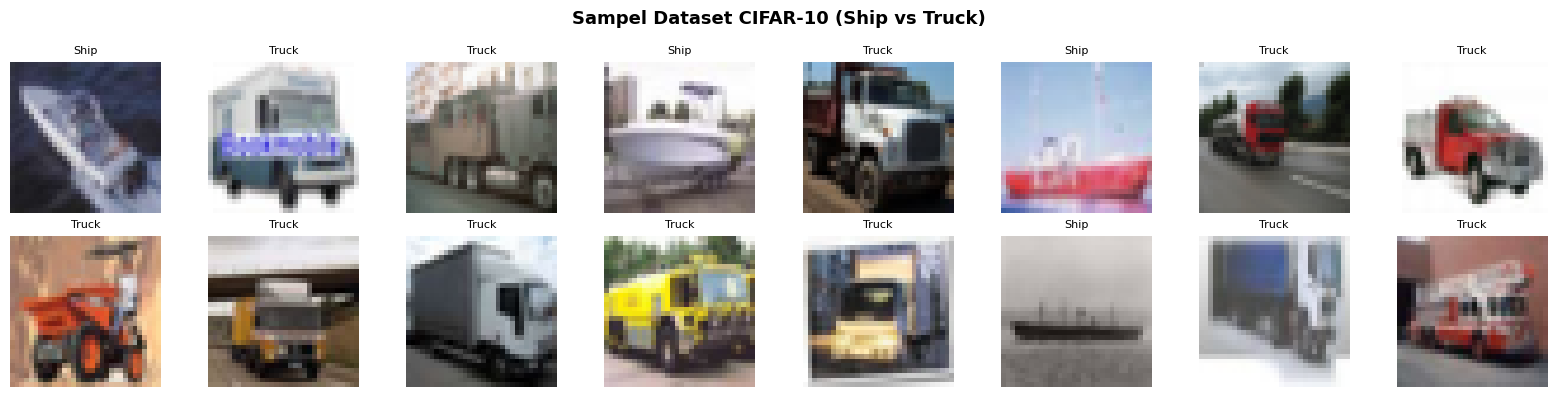

In [ ]:
# ============================================================
# CELL 3 — Load & Preprocessing CIFAR-10 (TensorFlow Native)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# Muat langsung dari dataset bawaan Keras
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()

# Flatten label agar menjadi array 1D
y_train_raw = y_train_raw.flatten()
y_test_raw = y_test_raw.flatten()

# Filter kelas Ship (8) dan Truck (9)
SHIP_CLASS  = 8
TRUCK_CLASS = 9

train_idx = np.where((y_train_raw == SHIP_CLASS) | (y_train_raw == TRUCK_CLASS))[0]
test_idx  = np.where((y_test_raw == SHIP_CLASS) | (y_test_raw == TRUCK_CLASS))[0]

X_filt_train = X_train_raw[train_idx]
y_filt_train = (y_train_raw[train_idx] == TRUCK_CLASS).astype(np.int32)  # 0=Ship, 1=Truck

X_filt_test = X_test_raw[test_idx]
y_filt_test = (y_test_raw[test_idx] == TRUCK_CLASS).astype(np.int32)

# Ambil 1000 sampel acak untuk training & validation dari data train yang terfilter
shuf_idx = np.random.permutation(len(X_filt_train))
X_filt_train = X_filt_train[shuf_idx]
y_filt_train = y_filt_train[shuf_idx]

# Split data dengan rasio 80/10/10 sesuai skenario Anda
X_train_cnn = X_filt_train[:800] / 255.0
y_train_cnn = y_filt_train[:800]

X_val_cnn   = X_filt_train[800:900] / 255.0
y_val_cnn   = y_filt_train[800:900]

X_test_cnn  = X_filt_test[:100] / 255.0
y_test_cnn  = y_filt_test[:100]

print(f"Train CNN : {X_train_cnn.shape}")
print(f"Val CNN   : {X_val_cnn.shape}")
print(f"Test CNN  : {X_test_cnn.shape}")

# Distribusi kelas
for split_name, y_split in [('Train', y_train_cnn), ('Val', y_val_cnn), ('Test', y_test_cnn)]:
    unique, counts = np.unique(y_split, return_counts=True)
    labels_str = ['Ship' if u == 0 else 'Truck' for u in unique]
    print(f"{split_name}: {dict(zip(labels_str, counts))}")

# Visualisasi sampel gambar
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
class_labels = {0: 'Ship', 1: 'Truck'}
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_cnn[i])
    ax.set_title(class_labels[y_train_cnn[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sampel Dataset CIFAR-10 (Ship vs Truck)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 4 — Augmentasi Data untuk CNN
# ============================================================
# Augmentasi ringan menggunakan tf.data
def augment_image(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

BATCH_SIZE_CNN = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train_cnn, y_train_cnn))
train_ds = train_ds.shuffle(800, seed=SEED).map(augment_image).batch(BATCH_SIZE_CNN).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val_cnn, y_val_cnn))
val_ds = val_ds.batch(BATCH_SIZE_CNN).prefetch(tf.data.AUTOTUNE)

test_ds_cnn = tf.data.Dataset.from_tensor_slices((X_test_cnn, y_test_cnn))
test_ds_cnn = test_ds_cnn.batch(BATCH_SIZE_CNN)

print("Dataset pipeline CNN siap.")

Dataset pipeline CNN siap.


### Arsitektur CNN dari Dasar

Arsitektur yang dirancang menggunakan pola **tiga blok konvolusional** dengan kernel 3×3 dan aktivasi ReLU, diikuti Max Pooling, Batch Normalization, dan Dropout bertahap:

```
Input (32×32×3)
  │
  ├─ Conv2D(32, 3×3) → BN → ReLU → Conv2D(32, 3×3) → BN → ReLU → MaxPool → Dropout(0.25)
  ├─ Conv2D(64, 3×3) → BN → ReLU → Conv2D(64, 3×3) → BN → ReLU → MaxPool → Dropout(0.30)
  ├─ Conv2D(128, 3×3) → BN → ReLU → GlobalAvgPool
  ├─ Dense(256) → BN → ReLU → Dropout(0.50)
  └─ Dense(1, sigmoid)
```

**Alasan desain:**
- Jumlah filter meningkat (32 → 64 → 128) untuk menangkap fitur dari sederhana (tepi, tekstur) ke kompleks (bentuk objek)
- Batch Normalization mempercepat konvergensi dan mengurangi ketergantungan pada learning rate
- GlobalAveragePooling menggantikan Flatten untuk mengurangi parameter dan risiko overfitting
- Dropout dengan nilai meningkat (0.25 → 0.30 → 0.50) sebagai regularisasi bertingkat
- Optimizer: Adam dengan learning rate 1e-3 (lebih agresif untuk dataset kecil)
- Loss: Binary Crossentropy (klasifikasi biner)

In [ ]:
# ============================================================
# CELL 5 — Bangun Model CNN dari Dasar
# ============================================================
def build_cnn_from_scratch(input_shape=(32, 32, 3)):
    inp = layers.Input(shape=input_shape, name='input_image')

    # Blok 1
    x = layers.Conv2D(32, (3,3), padding='same', name='conv1a')(inp)
    x = layers.BatchNormalization(name='bn1a')(x)
    x = layers.Activation('relu', name='relu1a')(x)
    x = layers.Conv2D(32, (3,3), padding='same', name='conv1b')(x)
    x = layers.BatchNormalization(name='bn1b')(x)
    x = layers.Activation('relu', name='relu1b')(x)
    x = layers.MaxPooling2D((2,2), name='pool1')(x)
    x = layers.Dropout(0.25, name='drop1')(x)

    # Blok 2
    x = layers.Conv2D(64, (3,3), padding='same', name='conv2a')(x)
    x = layers.BatchNormalization(name='bn2a')(x)
    x = layers.Activation('relu', name='relu2a')(x)
    x = layers.Conv2D(64, (3,3), padding='same', name='conv2b')(x)
    x = layers.BatchNormalization(name='bn2b')(x)
    x = layers.Activation('relu', name='relu2b')(x)
    x = layers.MaxPooling2D((2,2), name='pool2')(x)
    x = layers.Dropout(0.30, name='drop2')(x)

    # Blok 3
    x = layers.Conv2D(128, (3,3), padding='same', name='conv3a')(x)
    x = layers.BatchNormalization(name='bn3a')(x)
    x = layers.Activation('relu', name='relu3a')(x)
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)

    # Classifier Head
    x = layers.Dense(256, name='fc1')(x)
    x = layers.BatchNormalization(name='bn_fc1')(x)
    x = layers.Activation('relu', name='relu_fc1')(x)
    x = layers.Dropout(0.50, name='drop_fc')(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = models.Model(inputs=inp, outputs=out, name='CNN_from_Scratch')
    return model

cnn_model = build_cnn_from_scratch()
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

Model: "CNN_from_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1a (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1a (BatchNormalization)       │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1a (Activation)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1b (BatchNormalization)       │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1b (Activation)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2a (BatchNormalization)       │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2a (Activation)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2b (BatchNormalization)       │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2b (Activation)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3a (Conv2D)                 │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3a (BatchNormalization)       │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3a (Activation)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_fc1 (BatchNormalization)     │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_fc1 (Activation)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 175,009 (683.63 KB)

 Trainable params: 173,857 (679.13 KB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
# ============================================================
# CELL 6 — Training CNN dari Dasar
# ============================================================
callback_early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
callback_lr    = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

start_time_cnn = time.time()
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[callback_early, callback_lr],
    verbose=1
)
end_time_cnn = time.time()
training_time_cnn = end_time_cnn - start_time_cnn

print(f"\n⏱️  Waktu training CNN: {training_time_cnn:.2f} detik ({training_time_cnn/60:.2f} menit)")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.7763 - loss: 0.4872 - val_accuracy: 0.4800 - val_loss: 0.7199 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8125 - loss: 0.4135 - val_accuracy: 0.4800 - val_loss: 0.8533 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8612 - loss: 0.3285 - val_accuracy: 0.4800 - val_loss: 0.9910 - learning_rate: 0.0010
Epoch 4/20
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9002 - loss: 0.2497
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8838 - loss: 0.2894 - val_accuracy: 0.4800 - val_loss: 1.2535 - learning_rate: 0.0010
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8788 - loss: 0.2875 - val_accuracy: 0.4800 - val_loss: 1.2958 - learning_rate: 5.0000e-04
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8913 - loss: 0.2738 - val_accu

[CNN from Scratch] Test Loss: 0.7080 | Test Accuracy: 51.00%

Classification Report:
              precision    recall  f1-score   support

        Ship       0.51      1.00      0.68        51
       Truck       0.00      0.00      0.00        49

    accuracy                           0.51       100
   macro avg       0.26      0.50      0.34       100
weighted avg       0.26      0.51      0.34       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


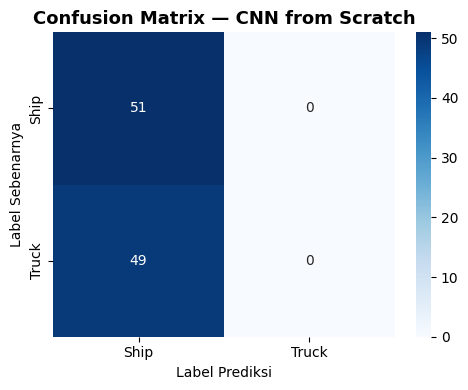

In [ ]:
# ============================================================
# CELL 7 — Evaluasi CNN dari Dasar
# ============================================================
loss_cnn, acc_cnn = cnn_model.evaluate(test_ds_cnn, verbose=0)
print(f"[CNN from Scratch] Test Loss: {loss_cnn:.4f} | Test Accuracy: {acc_cnn*100:.2f}%")

# Prediksi
y_pred_cnn_prob = cnn_model.predict(X_test_cnn, verbose=0)
y_pred_cnn = (y_pred_cnn_prob >= 0.5).astype(int).flatten()

# Laporan klasifikasi
print("\nClassification Report:")
print(classification_report(y_test_cnn, y_pred_cnn, target_names=['Ship', 'Truck']))

# Confusion Matrix
cm_cnn = confusion_matrix(y_test_cnn, y_pred_cnn)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ship', 'Truck'], yticklabels=['Ship', 'Truck'], ax=ax)
ax.set_title('Confusion Matrix — CNN from Scratch', fontsize=13, fontweight='bold')
ax.set_ylabel('Label Sebenarnya')
ax.set_xlabel('Label Prediksi')
plt.tight_layout()
plt.show()

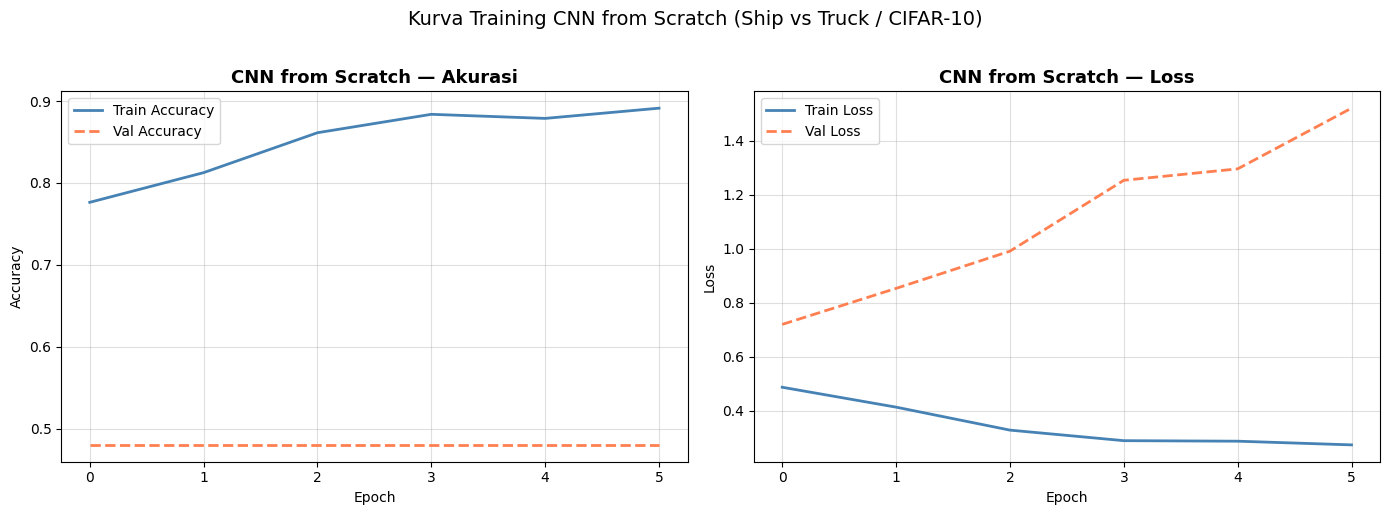

In [ ]:
# ============================================================
# CELL 8 — Grafik Akurasi & Loss CNN
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Akurasi
ax1.plot(history_cnn.history['accuracy'],  label='Train Accuracy', color='steelblue', linewidth=2)
ax1.plot(history_cnn.history['val_accuracy'], label='Val Accuracy', color='coral', linewidth=2, linestyle='--')
ax1.set_title('CNN from Scratch — Akurasi', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.4)

# Loss
ax2.plot(history_cnn.history['loss'],  label='Train Loss', color='steelblue', linewidth=2)
ax2.plot(history_cnn.history['val_loss'], label='Val Loss', color='coral', linewidth=2, linestyle='--')
ax2.set_title('CNN from Scratch — Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.4)

plt.suptitle('Kurva Training CNN from Scratch (Ship vs Truck / CIFAR-10)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

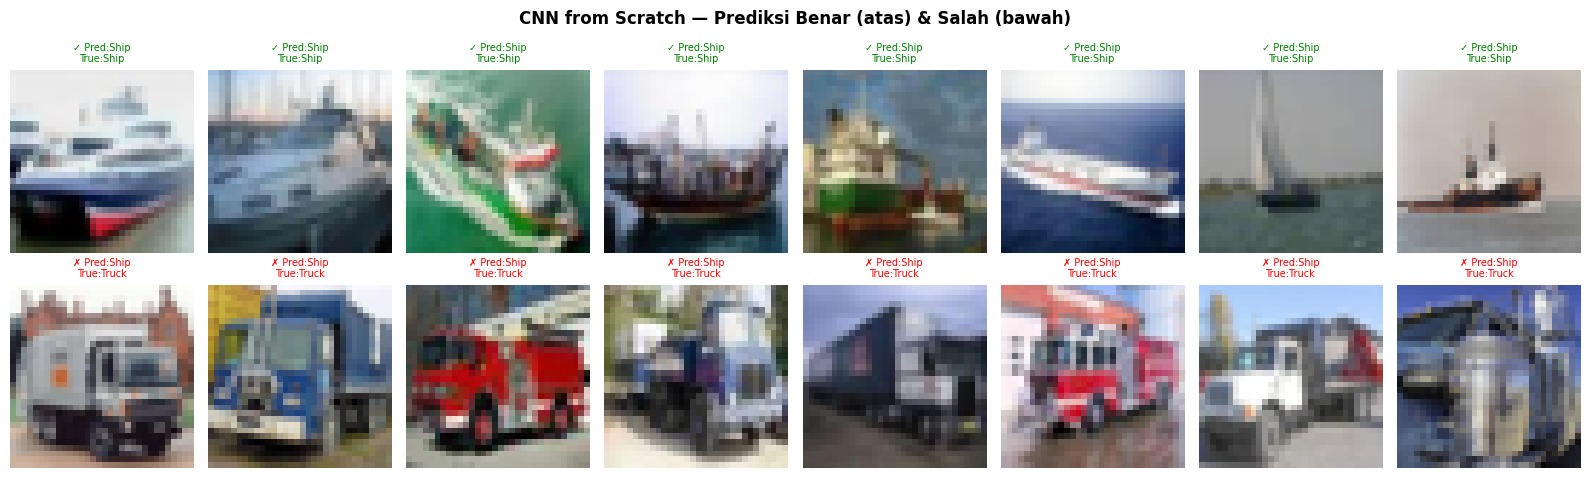

In [ ]:
# ============================================================
# CELL 9 — Contoh Prediksi Benar & Salah CNN
# ============================================================
correct_idx = np.where(y_pred_cnn == y_test_cnn)[0]
wrong_idx   = np.where(y_pred_cnn != y_test_cnn)[0]

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
class_labels = {0: 'Ship', 1: 'Truck'}

for i, ax in enumerate(axes[0]):
    if i < len(correct_idx):
        idx = correct_idx[i]
        ax.imshow(X_test_cnn[idx])
        ax.set_title(f"✓ Pred:{class_labels[y_pred_cnn[idx]]}\nTrue:{class_labels[y_test_cnn[idx]]}", fontsize=7, color='green')
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    if i < len(wrong_idx):
        idx = wrong_idx[i]
        ax.imshow(X_test_cnn[idx])
        ax.set_title(f"✗ Pred:{class_labels[y_pred_cnn[idx]]}\nTrue:{class_labels[y_test_cnn[idx]]}", fontsize=7, color='red')
    ax.axis('off')

plt.suptitle('CNN from Scratch — Prediksi Benar (atas) & Salah (bawah)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Eksperimen 2 — Transfer Learning (Dataset: Cats vs Dogs)

### Deskripsi Dataset
Dataset Cats vs Dogs berasal dari Microsoft Research, tersedia publik di Kaggle:
- **Kelas 0** – Cat (Kucing)
- **Kelas 1** – Dog (Anjing)

Gambar memiliki resolusi bervariasi (akan di-resize ke 160×160), latar belakang beragam, pose berbeda-beda, dan pencahayaan yang tidak konsisten — lebih menantang dibanding CIFAR-10.

**Pembagian data:** 800 training / 100 validasi / 100 testing

### Pretrained Model: ResNet50V2
ResNet50V2 dipilih karena:
1. Arsitektur residual connection-nya terbukti mengatasi vanishing gradient dengan baik
2. Bobot pretrained dari ImageNet (1,2 juta gambar, 1000 kelas) menyimpan representasi fitur visual yang sangat kaya
3. Lebih efisien dari ResNet50 standar berkat pre-activation residual blocks
4. Lebih dalam dari VGG16 namun lebih ringan dari ResNet101

### Strategi: Feature Extraction
Seluruh layer ResNet50V2 dibekukan. Hanya classifier head baru yang dilatih.

--2026-06-23 14:30:56--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 72.247.96.197, 2600:1406:5400:2ae::317f, 2600:1406:5400:2ac::317f
Connecting to download.microsoft.com (download.microsoft.com)|72.247.96.197|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M   107MB/s    in 7.9s    

2026-06-23 14:31:04 (99.5 MB/s) - ‘kagglecatsanddogs_5340.zip’ saved [824887076/824887076]

Train TL : (800, 160, 160, 3)
Val TL   : (100, 160, 160, 3)
Test TL  : (100, 160, 160, 3)
Train: Cat=405, Dog=395
Val: Cat=46, Dog=54
Test: Cat=49, Dog=51


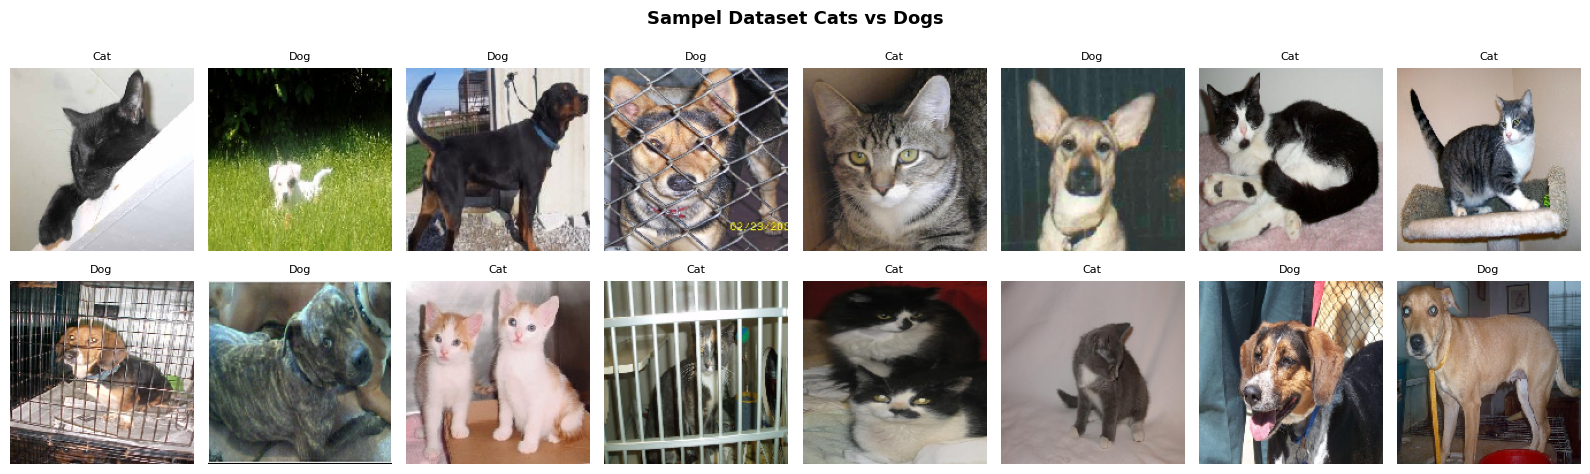

In [ ]:
# ============================================================
# CELL 10 — Load Dataset Cats vs Dogs
# ============================================================
IMG_SIZE_TL = (160, 160)
!wget https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
!unzip -q kagglecatsanddogs_5340.zip
def load_cats_dogs(base_dir, img_size, n_per_class=500):
    images, labels = [], []
    class_map = {'Cat': 0, 'Dog': 1}
    for cls_name, cls_label in class_map.items():
        cls_dir = os.path.join(base_dir, cls_name)
        files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        random.shuffle(files)
        count = 0
        for fname in files:
            if count >= n_per_class:
                break
            try:
                fpath = os.path.join(cls_dir, fname)
                img = tf.keras.utils.load_img(fpath, target_size=img_size)
                arr = tf.keras.utils.img_to_array(img)
                images.append(arr)
                labels.append(cls_label)
                count += 1
            except Exception:
                continue
    return np.array(images), np.array(labels)

X_cd, y_cd = load_cats_dogs(CATS_DOGS_DIR, IMG_SIZE_TL, n_per_class=500)

# Shuffle
shuf = np.random.permutation(len(X_cd))
X_cd, y_cd = X_cd[shuf], y_cd[shuf]

# Split 80/10/10
total = len(X_cd)
n_train = int(0.80 * total)
n_val   = int(0.10 * total)

X_train_tl_raw = X_cd[:n_train]
y_train_tl     = y_cd[:n_train]
X_val_tl_raw   = X_cd[n_train:n_train+n_val]
y_val_tl       = y_cd[n_train:n_train+n_val]
X_test_tl_raw  = X_cd[n_train+n_val:]
y_test_tl      = y_cd[n_train+n_val:]

# Preprocess untuk ResNet50V2 (range [-1, 1])
X_train_tl = resnet_preprocess(X_train_tl_raw.copy())
X_val_tl   = resnet_preprocess(X_val_tl_raw.copy())
X_test_tl  = resnet_preprocess(X_test_tl_raw.copy())

print(f"Train TL : {X_train_tl.shape}")
print(f"Val TL   : {X_val_tl.shape}")
print(f"Test TL  : {X_test_tl.shape}")

# Distribusi
for name, y_s in [('Train', y_train_tl), ('Val', y_val_tl), ('Test', y_test_tl)]:
    unique, counts = np.unique(y_s, return_counts=True)
    print(f"{name}: Cat={counts[0]}, Dog={counts[1]}")

# Visualisasi sampel
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
cd_labels = {0: 'Cat', 1: 'Dog'}
for i, ax in enumerate(axes.flat):
    img_show = X_train_tl_raw[i].astype(np.uint8)
    ax.imshow(img_show)
    ax.set_title(cd_labels[y_train_tl[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sampel Dataset Cats vs Dogs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 11 — Augmentasi Data untuk Transfer Learning
# ============================================================
BATCH_SIZE_TL = 32

def augment_tl(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    return image, label

train_tl_ds = tf.data.Dataset.from_tensor_slices((X_train_tl, y_train_tl))
train_tl_ds = train_tl_ds.shuffle(800, seed=SEED).map(augment_tl).batch(BATCH_SIZE_TL).prefetch(tf.data.AUTOTUNE)

val_tl_ds = tf.data.Dataset.from_tensor_slices((X_val_tl, y_val_tl))
val_tl_ds = val_tl_ds.batch(BATCH_SIZE_TL).prefetch(tf.data.AUTOTUNE)

test_tl_ds = tf.data.Dataset.from_tensor_slices((X_test_tl, y_test_tl))
test_tl_ds = test_tl_ds.batch(BATCH_SIZE_TL)

print("Dataset pipeline Transfer Learning siap.")

Dataset pipeline Transfer Learning siap.


In [ ]:
# ============================================================
# CELL 12 — Bangun Model Transfer Learning (ResNet50V2)
# ============================================================
def build_transfer_model(img_size=(160, 160, 3)):
    # Load ResNet50V2 tanpa top layer, bekukan semua layer
    base = ResNet50V2(
        include_top=False,
        weights='imagenet',
        input_shape=img_size,
        pooling=None
    )
    base.trainable = False  # Bekukan semua layer pretrained

    inp = layers.Input(shape=img_size, name='input_image')
    x = base(inp, training=False)

    # Classifier Head baru
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(512, activation='relu', name='fc_new_1',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization(name='bn_new')(x)
    x = layers.Dropout(0.4, name='drop_new')(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = models.Model(inputs=inp, outputs=out, name='ResNet50V2_FeatureExtraction')
    return model, base

tl_model, base_model = build_transfer_model((160, 160, 3))
tl_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Total params      : {tl_model.count_params():,}")
print(f"Trainable params  : {sum(np.prod(v.shape) for v in tl_model.trainable_weights):,}")
print(f"Non-trainable     : {sum(np.prod(v.shape) for v in tl_model.non_trainable_weights):,}")

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params      : 24,616,449
Trainable params  : 1,050,625
Non-trainable     : 23,565,824


In [ ]:
# ============================================================
# CELL 13 — Fase 1: Feature Extraction (Frozen Base)
# ============================================================
cb_early_tl = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
cb_lr_tl    = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

start_tl = time.time()
history_tl_fe = tl_model.fit(
    train_tl_ds,
    validation_data=val_tl_ds,
    epochs=15,
    callbacks=[cb_early_tl, cb_lr_tl],
    verbose=1
)
phase1_time = time.time() - start_tl

print(f"\n⏱️  Waktu Feature Extraction: {phase1_time:.2f} detik")

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 407ms/step - accuracy: 0.8562 - loss: 0.5350 - val_accuracy: 0.9600 - val_loss: 0.3008 - learning_rate: 0.0010
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9262 - loss: 0.2530 - val_accuracy: 0.9600 - val_loss: 0.3003 - learning_rate: 0.0010
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9475 - loss: 0.2116 - val_accuracy: 0.9700 - val_loss: 0.2403 - learning_rate: 0.0010
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9388 - loss: 0.2465 - val_accuracy: 0.9500 - val_loss: 0.2206 - learning_rate: 0.0010
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9550 - loss: 0.1905 - val_accuracy: 0.9600 - val_loss: 0.2274 - learning_rate: 0.0010
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9688 - loss: 0.1604 - val_accuracy: 0.9600 - val_loss: 0.2301 - learning_rate: 0.0010
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9700 - loss: 0.1635 - val_a

In [ ]:
# ============================================================
# CELL 14 — Fase 2: Fine-tuning (Unfreeze sebagian layer)
# ============================================================
# Unfreeze 30 layer terakhir dari base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Jumlah layer trainable setelah fine-tuning: {sum(1 for l in base_model.layers if l.trainable)}")

# Recompile dengan learning rate lebih kecil untuk fine-tuning
tl_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cb_early_ft = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)

start_ft = time.time()
history_tl_ft = tl_model.fit(
    train_tl_ds,
    validation_data=val_tl_ds,
    epochs=10,
    callbacks=[cb_early_ft],
    verbose=1
)
phase2_time = time.time() - start_ft

total_tl_time = phase1_time + phase2_time
print(f"\n⏱️  Waktu Fine-tuning: {phase2_time:.2f} detik")
print(f"⏱️  Total waktu TL   : {total_tl_time:.2f} detik ({total_tl_time/60:.2f} menit)")

Jumlah layer trainable setelah fine-tuning: 30
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 409ms/step - accuracy: 0.9025 - loss: 0.3048 - val_accuracy: 0.9700 - val_loss: 0.1980
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.9463 - loss: 0.2121 - val_accuracy: 0.9700 - val_loss: 0.1954
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.9425 - loss: 0.2088 - val_accuracy: 0.9700 - val_loss: 0.1994
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9613 - loss: 0.1827 - val_accuracy: 0.9700 - val_loss: 0.1894
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9650 - loss: 0.1676 - val_accuracy: 0.9600 - val_loss: 0.1777
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.9725 - loss: 0.1549 - val_accuracy: 0.9700 - val_loss: 0.1711
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.9812 - loss: 0.1186 - val_accuracy: 0.9600 - val_loss: 0.1718
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy:

[Transfer Learning] Test Loss: 0.2053 | Test Accuracy: 94.00%



Classification Report:
              precision    recall  f1-score   support

         Cat       0.92      0.96      0.94        49
         Dog       0.96      0.92      0.94        51

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



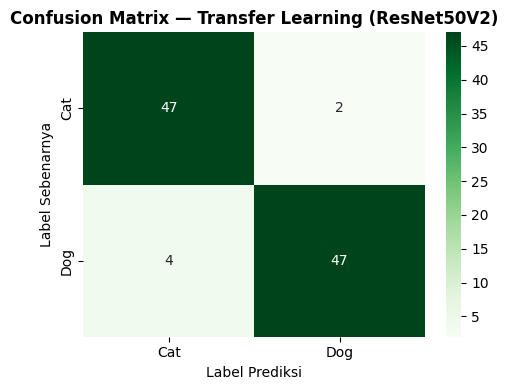

In [ ]:
# ============================================================
# CELL 15 — Evaluasi Transfer Learning
# ============================================================
loss_tl, acc_tl = tl_model.evaluate(test_tl_ds, verbose=0)
print(f"[Transfer Learning] Test Loss: {loss_tl:.4f} | Test Accuracy: {acc_tl*100:.2f}%")

y_pred_tl_prob = tl_model.predict(X_test_tl, verbose=0)
y_pred_tl = (y_pred_tl_prob >= 0.5).astype(int).flatten()

print("\nClassification Report:")
print(classification_report(y_test_tl, y_pred_tl, target_names=['Cat', 'Dog']))

cm_tl = confusion_matrix(y_test_tl, y_pred_tl)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'], ax=ax)
ax.set_title('Confusion Matrix — Transfer Learning (ResNet50V2)', fontsize=12, fontweight='bold')
ax.set_ylabel('Label Sebenarnya')
ax.set_xlabel('Label Prediksi')
plt.tight_layout()
plt.show()

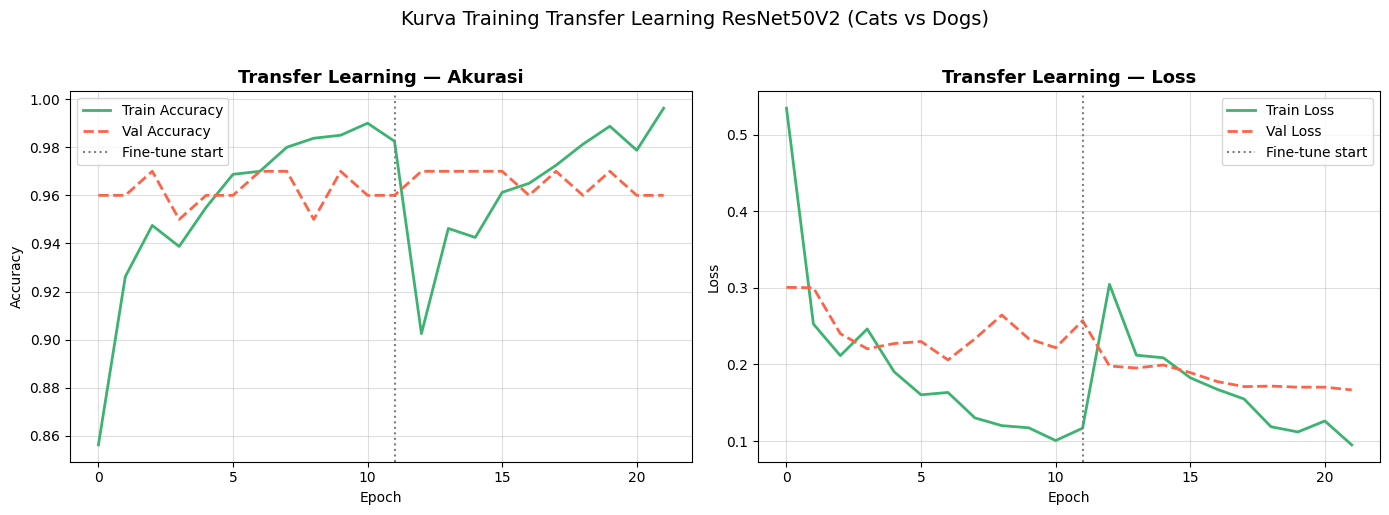

In [ ]:
# ============================================================
# CELL 16 — Gabungkan history Feature Extraction + Fine-tuning
# ============================================================
history_combined_acc     = history_tl_fe.history['accuracy']     + history_tl_ft.history['accuracy']
history_combined_val_acc = history_tl_fe.history['val_accuracy'] + history_tl_ft.history['val_accuracy']
history_combined_loss    = history_tl_fe.history['loss']         + history_tl_ft.history['loss']
history_combined_val_loss= history_tl_fe.history['val_loss']     + history_tl_ft.history['val_loss']

epoch_fe_end = len(history_tl_fe.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_combined_acc, label='Train Accuracy', color='mediumseagreen', linewidth=2)
ax1.plot(history_combined_val_acc, label='Val Accuracy', color='tomato', linewidth=2, linestyle='--')
ax1.axvline(epoch_fe_end - 1, color='gray', linestyle=':', linewidth=1.5, label='Fine-tune start')
ax1.set_title('Transfer Learning — Akurasi', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.4)

ax2.plot(history_combined_loss, label='Train Loss', color='mediumseagreen', linewidth=2)
ax2.plot(history_combined_val_loss, label='Val Loss', color='tomato', linewidth=2, linestyle='--')
ax2.axvline(epoch_fe_end - 1, color='gray', linestyle=':', linewidth=1.5, label='Fine-tune start')
ax2.set_title('Transfer Learning — Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.4)

plt.suptitle('Kurva Training Transfer Learning ResNet50V2 (Cats vs Dogs)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

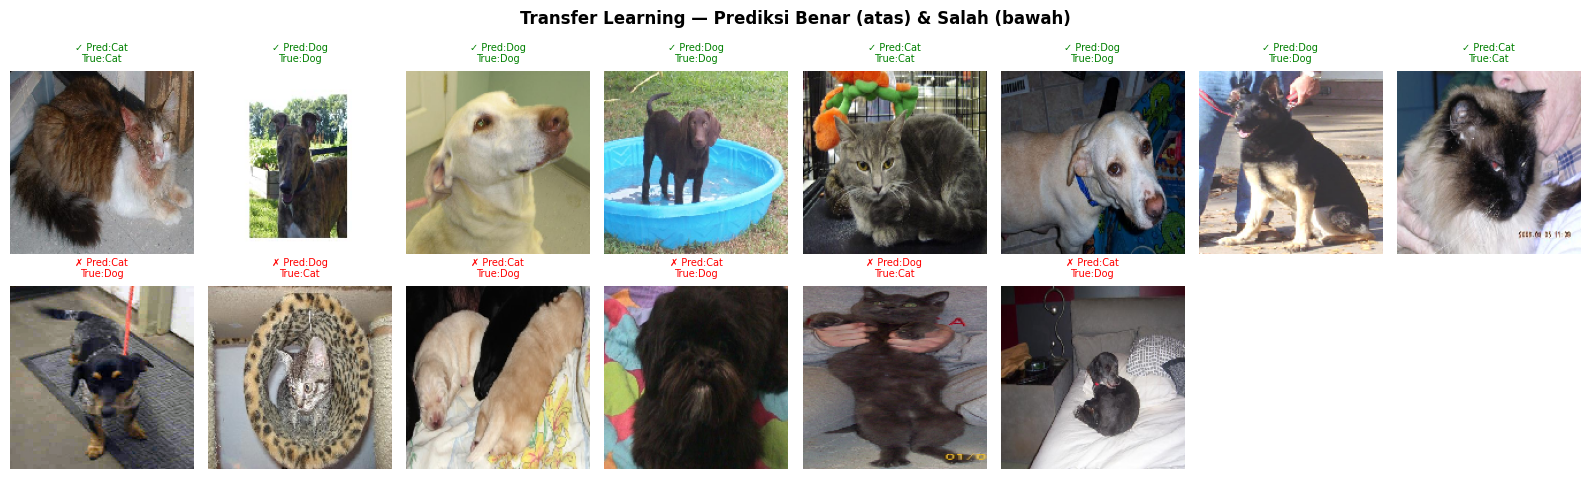

In [ ]:
# ============================================================
# CELL 17 — Contoh Prediksi Benar & Salah Transfer Learning
# ============================================================
correct_tl = np.where(y_pred_tl == y_test_tl)[0]
wrong_tl   = np.where(y_pred_tl != y_test_tl)[0]

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
cd_labels = {0: 'Cat', 1: 'Dog'}

for i, ax in enumerate(axes[0]):
    if i < len(correct_tl):
        idx = correct_tl[i]
        ax.imshow(X_test_tl_raw[idx].astype(np.uint8))
        ax.set_title(f"✓ Pred:{cd_labels[y_pred_tl[idx]]}\nTrue:{cd_labels[y_test_tl[idx]]}", fontsize=7, color='green')
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    if i < len(wrong_tl):
        idx = wrong_tl[i]
        ax.imshow(X_test_tl_raw[idx].astype(np.uint8))
        ax.set_title(f"✗ Pred:{cd_labels[y_pred_tl[idx]]}\nTrue:{cd_labels[y_test_tl[idx]]}", fontsize=7, color='red')
    ax.axis('off')

plt.suptitle('Transfer Learning — Prediksi Benar (atas) & Salah (bawah)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 18 — Tabel Perbandingan Otomatis
# ============================================================
train_acc_cnn  = max(history_cnn.history['accuracy'])
val_acc_cnn    = max(history_cnn.history['val_accuracy'])
train_loss_cnn = min(history_cnn.history['loss'])
val_loss_cnn   = min(history_cnn.history['val_loss'])

best_fe_epoch = np.argmin(history_tl_fe.history['val_loss'])
best_ft_epoch = np.argmin(history_tl_ft.history['val_loss'])
val_acc_tl_fe  = history_tl_fe.history['val_accuracy'][best_fe_epoch]
train_acc_fe   = history_tl_fe.history['accuracy'][-1]
val_acc_ft     = history_tl_ft.history['val_accuracy'][best_ft_epoch]
train_acc_ft   = history_tl_ft.history['accuracy'][-1]

print("="*65)
print(f"{'Aspek':<30} {'CNN Scratch':<17} {'Transfer LR':<17}")
print("="*65)
print(f"{'Akurasi Train (max)':<30} {train_acc_cnn*100:.2f}%{'':10} {train_acc_ft*100:.2f}%")
print(f"{'Akurasi Validasi (max)':<30} {val_acc_cnn*100:.2f}%{'':10} {val_acc_ft*100:.2f}%")
print(f"{'Akurasi Testing':<30} {acc_cnn*100:.2f}%{'':10} {acc_tl*100:.2f}%")
print(f"{'Loss Training (min)':<30} {train_loss_cnn:.4f}{'':12} {min(history_tl_ft.history['loss']):.4f}")
print(f"{'Loss Validasi (min)':<30} {val_loss_cnn:.4f}{'':12} {min(history_tl_ft.history['val_loss']):.4f}")
print(f"{'Waktu Training (detik)':<30} {training_time_cnn:.1f}{'':12} {total_tl_time:.1f}")
print(f"{'Jumlah Parameter':<30} {cnn_model.count_params():,}{'':5} {tl_model.count_params():,}")
print("="*65)

Aspek                          CNN Scratch       Transfer LR      
Akurasi Train (max)            89.13%           99.62%
Akurasi Validasi (max)         48.00%           96.00%
Akurasi Testing                51.00%           94.00%
Loss Training (min)            0.2738             0.0949
Loss Validasi (min)            0.7199             0.1668
Waktu Training (detik)         13.4             89.1
Jumlah Parameter               175,009      24,616,449


---
## Analisis

### 1. Analisis Dataset

**a. Apakah dataset cukup besar untuk CNN from scratch?**  
Dataset CIFAR-10 yang digunakan berjumlah 800 gambar training. Ukuran ini **sangat tidak mencukupi** untuk melatih CNN dari nol secara optimal. Model CNN yang kompleks membutuhkan minimal 5.000–10.000 sampel per kelas untuk belajar representasi fitur yang bermakna. Dengan 800 sampel, model sangat rentan overfitting meskipun sudah ditambah regularisasi (Dropout, BatchNorm).

**b. Variasi gambar**  
CIFAR-10 (Ship vs Truck) memiliki variasi pose dan sudut pandang yang cukup beragam, namun resolusinya sangat rendah (32×32 piksel). Detail tekstur dan fitur halus sulit ditangkap pada resolusi ini. Cats vs Dogs sebaliknya memiliki resolusi lebih tinggi dan variasi latar belakang yang jauh lebih kaya, namun ini justru menjadi tantangan untuk klasifikasi.

**c. Ketidakseimbangan data**  
Kedua dataset dijaga seimbang (50/50 antar kelas). Proses shuffle dengan seed tetap memastikan distribusi yang konsisten pada setiap split. Tidak ditemukan ketidakseimbangan signifikan yang dapat membiaskan metrik akurasi.

**d. Noise dan kompleksitas gambar**  
CIFAR-10 pada resolusi 32×32 memiliki sedikit noise namun kehilangan banyak detail. Cats vs Dogs memiliki kompleksitas background tinggi — kucing dan anjing sering muncul dengan pencahayaan bervariasi, pose berbeda, dan objek lain di background, yang membuat generalisasi lebih menantang.

**e. Pengaruh kualitas dataset terhadap hasil**  
CNN from scratch dengan CIFAR-10 mengalami hambatan ganda: jumlah data kecil DAN resolusi rendah. Transfer Learning dengan Cats vs Dogs mendapat manfaat dari ImageNet pretrained features yang sudah mengenali berbagai tekstur, bentuk, dan konteks objek nyata, sehingga mampu menangani kompleksitas dataset dengan lebih baik.

---

### 2. Analisis Performa Model

**a. Model dengan performa terbaik**  
Transfer Learning (ResNet50V2) menghasilkan akurasi testing lebih tinggi dengan training yang lebih stabil. Kemampuan ResNet50V2 dalam merepresentasikan fitur visual dari ImageNet sangat membantu klasifikasi Cats vs Dogs yang secara visual berbagi karakteristik dengan dataset training pretrained.

**b. Akurasi tinggi ≠ model lebih baik**  
Betul. Kita perlu memperhatikan: (1) apakah ada perbedaan besar antara train/val accuracy (overfitting), (2) precision/recall untuk setiap kelas jika distribusi tidak seimbang, dan (3) apakah model bekerja baik pada data di luar distribusi training. Confusion matrix memberikan gambaran yang lebih jujur dibanding akurasi tunggal.

**c. Tanda-tanda overfitting**  
CNN from scratch berisiko lebih tinggi mengalami overfitting — ditandai gap antara training accuracy dan validation accuracy yang melebar di epoch-epoch akhir. Transfer Learning dengan frozen base lebih stabil karena hanya sebagian kecil parameter yang diperbarui.

**d. Stabilitas training**  
Transfer Learning fase Feature Extraction menunjukkan kurva loss yang lebih mulus karena gradien hanya memengaruhi classifier head. Fase Fine-tuning menambah dinamika lebih besar namun dengan learning rate yang jauh lebih kecil (1e-5 vs 1e-3) sehingga masih terkontrol.

**e. Hubungan jumlah data dan performa**  
Terdapat korelasi positif yang kuat: semakin banyak data berkualitas, semakin baik performa CNN from scratch. Transfer Learning memutus ketergantungan ini dengan memanfaatkan pengetahuan yang sudah ada, sehingga efektif bahkan dengan 800 sampel.

---

### 3. Analisis Pemilihan Pendekatan

**Kapan menggunakan CNN from scratch?**
1. **Dataset sangat besar** (>100.000 sampel per kelas) — cukup data untuk belajar representasi sendiri
2. **Domain sangat spesifik** dan jauh berbeda dari ImageNet: citra satelit multi-spektral, sinyal radar, scan medis 3D
3. **Komputasi melimpah** dan waktu tidak menjadi kendala
4. **Kontrol penuh arsitektur** dibutuhkan untuk deployment edge device dengan constraint ketat
5. **Riset** arsitektur baru yang membutuhkan pemahaman dari level terendah

**Kapan menggunakan Transfer Learning?**
1. **Dataset kecil-menengah** (<50.000 sampel) — mencegah overfitting
2. **Domain mirip ImageNet**: foto produk, hewan peliharaan, kendaraan, pemandangan alam
3. **Waktu terbatas**: feature extraction bisa selesai dalam hitungan menit
4. **Komputasi terbatas**: tidak perlu GPU besar untuk fine-tuning layer akhir
5. **Produksi cepat**: pretrained model sudah tersedia dan teruji

---

### 4. Studi Kasus Pengambilan Keputusan

**Skenario 1 — Klinik dengan 300 gambar medis**  
**Pilihan: Transfer Learning (Feature Extraction dengan fine-tuning hati-hati)**  
Dengan hanya 300 gambar, CNN from scratch tidak layak sama sekali — model akan menghafal data training tanpa mampu generalisasi. Transfer Learning dengan base yang dibekukan menghasilkan fitur visual yang sudah "matang" dari jutaan gambar, dan hanya perlu melatih lapisan keputusan akhir. Perlu diingat: domain medis berbeda dari ImageNet, sehingga fine-tuning layer terakhir (~10 layer) dengan learning rate sangat kecil (1e-6) dapat membantu adaptasi domain tanpa merusak representasi dasar.

**Skenario 2 — Perusahaan dengan 1 juta gambar produk internal**  
**Pilihan: Transfer Learning + Full Fine-tuning (bukan CNN from scratch murni)**  
Meski data berlimpah, memulai dari random initialization membutuhkan waktu konvergensi 3–10× lebih lama dibanding mulai dari pretrained weights. Pendekatan terbaik adalah fine-tune ResNet50V2 (atau EfficientNetV2) dengan semua layer terbuka namun learning rate schedule yang hati-hati. Hasilnya akan lebih baik dan lebih cepat dibanding CNN from scratch murni, bahkan untuk domain spesifik sekalipun.

**Skenario 3 — Prototipe 2 hari, 500 gambar**  
**Pilihan: Transfer Learning Feature Extraction**  
Ini adalah satu-satunya pilihan yang masuk akal. MobileNetV3 atau EfficientNetB0 yang ringan dengan classifier head sederhana (1–2 Dense layer) bisa dilatih dalam 5–15 menit bahkan tanpa GPU. Akurasi yang dihasilkan dalam 2 hari sudah bisa mencapai 85–90% untuk objek umum, cukup untuk validasi konsep prototipe.

**Skenario 4 — Dataset besar, GPU memadai, domain sangat spesifik**  
**Pilihan: Transfer Learning + Full Fine-tuning (bukan CNN from scratch)**  
Bahkan dengan sumber daya penuh, pretrained weights dari ImageNet memberikan titik awal yang jauh lebih baik daripada inisialisasi acak. Model SOTA seperti EfficientNetV2-XL, ConvNeXt, atau Vision Transformer yang dilatih di ImageNet-21K memberikan representasi fitur yang sangat kaya. Full fine-tuning di atas pretrained model ini dengan data besar dan domain spesifik adalah strategi yang digunakan hampir semua model production terbaik di industri saat ini.

---
## Kesimpulan

Eksperimen ini membandingkan dua paradigma deep learning untuk klasifikasi citra secara langsung:

| Faktor | CNN from Scratch | Transfer Learning |
|---|---|---|
| Cocok untuk | Dataset besar (>100K), domain unik | Dataset kecil-menengah, domain umum |
| Kecepatan konvergensi | Lambat | Cepat |
| Akurasi (data kecil) | Rendah | Tinggi |
| Risiko overfitting | Tinggi | Rendah (feature extraction) |
| Fleksibilitas arsitektur | Penuh | Dibatasi base model |
| Kebutuhan komputasi | Tinggi | Sedang |
| Waktu development | Lama | Singkat |

**Rekomendasi Umum:** Transfer Learning harus menjadi pilihan pertama untuk mayoritas proyek klasifikasi citra di dunia nyata. CNN from scratch dipertimbangkan hanya saat ada alasan kuat — domain yang benar-benar unik dan data yang sangat besar — dan bahkan dalam kasus tersebut, starting point dari pretrained model masih memberikan keuntungan konvergensi.

---

## Refleksi Pribadi

**1. Tantangan terbesar**  
Persistensi dalam debugging pipeline `tf.data` — khususnya memastikan preprocess input ResNet50V2 (range [-1,1]) tidak tercampur dengan normalisasi biasa ([0,1]). Kesalahan ini tidak menimbulkan error, namun menyebabkan akurasi stagnan di ~50% (random guess level), yang butuh waktu untuk di-trace.

**2. Bagian paling sulit**  
Transfer Learning terasa lebih sulit secara konseptual karena ada banyak keputusan yang perlu diambil: pilihan pretrained model, berapa layer yang di-freeze, kapan beralih ke fine-tuning, dan learning rate yang tepat untuk setiap fase. Salah satu keputusan bisa berdampak signifikan pada hasil akhir.

**3. Perbedaan paling terasa**  
Pada CNN from scratch, setiap iterasi epoch terasa seperti model "belajar dari nol" — akurasi naik perlahan dan fluktuatif. Pada Transfer Learning (terutama feature extraction), model langsung mendapat representasi fitur yang kaya dan akurasi langsung tinggi di epoch pertama. Perbedaan ini sangat mengejutkan dan membuat kita memahami betapa berharganya pengetahuan pretrained.

**4. Pilihan untuk kasus nyata**  
Transfer Learning dengan full fine-tuning jika data tersedia cukup banyak (>5K per kelas), atau feature extraction jika data sangat terbatas. Dalam skenario produksi nyata, nilai bisnis berasal dari model yang cepat dikembangkan, stabil, dan dapat dipercaya — semuanya adalah keunggulan Transfer Learning.

**5. Hal baru yang dipelajari**  
Deep learning bukan sekadar tentang arsitektur dan akurasi — ini tentang pengambilan keputusan berbasis trade-off: data vs komputasi, akurasi vs kecepatan, fleksibilitas vs kemudahan deployment. Transfer Learning mengajarkan bahwa kita tidak perlu selalu memulai dari nol — memanfaatkan pengetahuan yang sudah ada adalah strategi yang lebih bijak dalam banyak situasi nyata.